## In this notebook we use various training strategies to train our PNN on MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
#sys.path.append('G:/Utilisateurs/anas.skalli/Desktop/ONN_experiments/Simulation/Nonlinear_oscillator_net/nonlinear_oscillator_network/Utils')
sys.path.append('/home/anas/Desktop/Simulations/Training_NLO/nonlinear_oscillator_network/Utils')

from NN_utils import *
import torch
import torch.nn as nn
from torchvision import datasets, transforms
#from torchsummary import summary
import time
from types import SimpleNamespace
import pickle
import gc
from optimization_algorithms import *

In [2]:
transform_data = transforms.Compose([
    transforms.ToTensor()
    #transforms.Normalize((0.2868,), (0.3524,))
])

MNIST_train = datasets.MNIST(root='./data', train=True, transform=transform_data, download=True)
MNIST_test = datasets.MNIST(root='./data', train=False, transform=transform_data, download=True)

train_loader_MNIST = torch.utils.data.DataLoader(dataset=MNIST_train, batch_size=1000, shuffle=True)
test_loader_MNIST = torch.utils.data.DataLoader(dataset=MNIST_test, batch_size=10000, shuffle=False)

X_train_MNIST, Y_train_MNIST = next(iter(train_loader_MNIST))
X_test_MNIST, Y_test_MNIST = next(iter(test_loader_MNIST))

In [ ]:
N_neurons_vec = [5, 10, 20, 30, 50, 75, 100]
#N_neurons_vec = [100]

n_epochs = 100
results = []

stats = 3

start_time = time.time()
for s in range(stats):
    for n_neurons in N_neurons_vec:
    
       
        #Initialize RNN
        
        RNN_params = {
            "N_in": 784,               # e.g., flattened 28x28 FashionMNIST image
            "N_out": 10,               # number of classes in FashionMNIST
            "N_neurons": n_neurons,          # number of hidden units per RNN layer
            "N_layers": 3             # depth of the RNN
        }
        
        model = Oscillator_RNN_dyn(params=RNN_params)
        
        
        
        model.init_esn_weights(reservoir = True)
        model.dt = 0.1
        model.eps_int = 1e-4
        model.alpha=3
        model.max_steps=40
        model.save_activations = False
        
        # for layer in model.W_in:
        #     for param in layer.parameters():
        #         param.requires_grad = False
                
        # model.W_input.weight.requires_grad = False
        # model.W_input.bias.requires_grad = False
        
        
        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        
        print(f'Using {n_neurons} per layer, run {s+1}, number of parameters {model.count_parameters()}')
        D = train_BP_torch(model, n_epochs, train_loader_MNIST, test_loader_MNIST, loss, optimizer)
    
        results.append(D)
        
        del model
        del optimizer
        torch.cuda.empty_cache()
        gc.collect()

end_time = time.time()
print(f'Total time = {end_time- start_time} s')

Using 5 per layer, run 1, number of parameters 4045
Using cuda device
Oscillator_RNN_dyn(
  (W_input): Linear(in_features=784, out_features=5, bias=True)
  (W_in): ModuleList(
    (0-1): 2 x Linear(in_features=5, out_features=5, bias=True)
  )
  (W_recurrent): ModuleList(
    (0-2): 3 x SparseLinear()
  )
  (W_out): Linear(in_features=5, out_features=10, bias=True)
)
Epoch [1/100], Step [1/60], Loss: 2.329305648803711, Test Accuracy: 10.09%
Epoch [1/100], Step [10/60], Loss: 2.3252384662628174, Test Accuracy: 10.09%
Epoch [1/100], Step [20/60], Loss: 2.3241100311279297, Test Accuracy: 10.09%
Epoch [1/100], Step [30/60], Loss: 2.3095791339874268, Test Accuracy: 10.09%
Epoch [1/100], Step [40/60], Loss: 2.309187412261963, Test Accuracy: 10.09%
Epoch [1/100], Step [50/60], Loss: 2.296316146850586, Test Accuracy: 10.09%
Epoch [1/100], Step [60/60], Loss: 2.2870075702667236, Test Accuracy: 10.09%
Epoch [2/100], Step [1/60], Loss: 2.296515464782715, Test Accuracy: 10.09%
Epoch [2/100], Step 

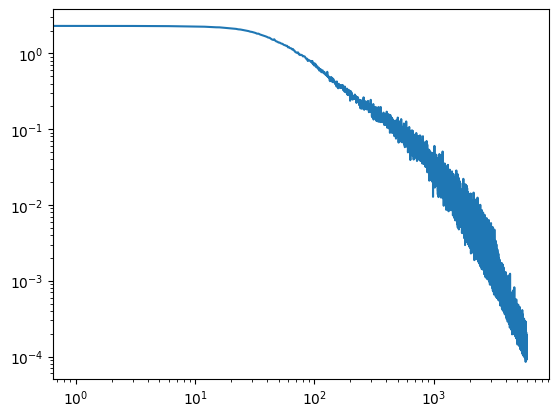

In [4]:
plt.loglog(D['train_loss'])

In [7]:
with open('results/results_paramscan_PNN_BP_MNIST.pkl', 'wb') as f:
    pickle.dump(results, f)     

In [5]:
test_loss_vec = []
test_loss_std = []
test_acc_vec = []
test_acc_std = []
train_loss_vec = []
train_loss_std = []
n_params = []

dummy = np.reshape(results, [stats, len(N_neurons_vec)])
top_k = 10  # Number of best points to average over

for i in range(len(N_neurons_vec)):
    train_loss_runs = []
    test_loss_runs = []
    test_acc_runs = []
    
    for j in range(stats):
        train_loss = np.array(dummy[j, i]['train_loss'])
        test_loss = np.array(dummy[j, i]['test_loss'])
        test_acc = np.array(dummy[j, i]['test_acc'])

        # Take mean over best 10 points for each metric
        best_train_loss = np.mean(np.sort(train_loss)[:top_k])
        best_test_loss = np.mean(np.sort(test_loss)[:top_k])
        best_test_acc = np.mean(np.sort(test_acc)[-top_k:])  # top accuracy

        train_loss_runs.append(best_train_loss)
        test_loss_runs.append(best_test_loss)
        test_acc_runs.append(best_test_acc)

    train_loss_vec.append(np.mean(train_loss_runs))
    test_loss_vec.append(np.mean(test_loss_runs))
    test_acc_vec.append(np.mean(test_acc_runs))

    train_loss_std.append(np.std(train_loss_runs))
    test_loss_std.append(np.std(test_loss_runs))
    test_acc_std.append(np.std(test_acc_runs))

    n_params.append(dummy[0, i]['n_params'])

n_params = np.array(n_params)


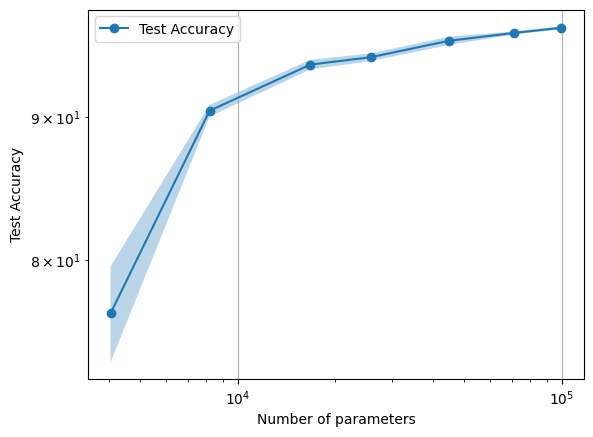

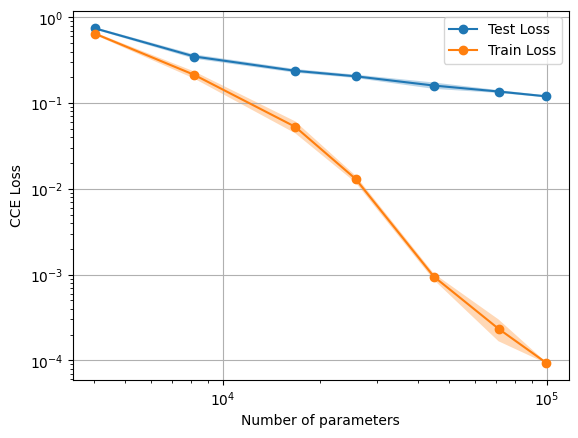

In [6]:
# Accuracy plot
plt.figure()
plt.loglog(n_params, test_acc_vec, '-o', label='Test Accuracy')
plt.fill_between(n_params,
                 np.array(test_acc_vec) - np.array(test_acc_std),
                 np.array(test_acc_vec) + np.array(test_acc_std),
                 alpha=0.3)
plt.xlabel('Number of parameters')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.loglog(n_params, test_loss_vec, '-o', label='Test Loss')
plt.fill_between(n_params,
                 np.array(test_loss_vec) - np.array(test_loss_std),
                 np.array(test_loss_vec) + np.array(test_loss_std),
                 alpha=0.3)

plt.loglog(n_params, train_loss_vec, '-o', label='Train Loss')
plt.fill_between(n_params,
                 np.array(train_loss_vec) - np.array(train_loss_std),
                 np.array(train_loss_vec) + np.array(train_loss_std),
                 alpha=0.3)

plt.xlabel('Number of parameters')
plt.ylabel('CCE Loss')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
N_neurons_vec = [5, 10, 20, 30, 50, 75, 100]
N_neurons_vec = [100]

n_epochs = 100
results = []

stats = 3

start_time = time.time()
for s in range(stats):
    for n_neurons in N_neurons_vec:
    
       
        #Initialize RNN
        
        RNN_params = {
            "N_in": 784,               # e.g., flattened 28x28 FashionMNIST image
            "N_out": 10,               # number of classes in FashionMNIST
            "N_neurons": n_neurons,          # number of hidden units per RNN layer
            "N_layers": 3             # depth of the RNN
        }
        
        model = Oscillator_RNN_compressed(params=RNN_params,r_compress=8,compression_method = 'Lora')
        
        
        
        model.init_esn_weights(reservoir = True)
        model.dt = 0.1
        model.eps_int = 1e-4
        model.alpha=3
        model.max_steps=40
        model.save_activations = False
        
        # for layer in model.W_in:
        #     for param in layer.parameters():
        #         param.requires_grad = False
                
        # model.W_input.weight.requires_grad = False
        # model.W_input.bias.requires_grad = False
        
        
        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        
        print(f'Using {n_neurons} per layer, run {s+1}, number of parameters {model.count_parameters()}')
        D = train_BP_torch(model, n_epochs, train_loader_MNIST, test_loader_MNIST, loss, optimizer)
    
        results.append(D)
        
        del model
        del optimizer
        torch.cuda.empty_cache()
        gc.collect()

end_time = time.time()
print(f'Total time = {end_time- start_time} s')

Using 100 per layer, run 1, number of parameters 11282
Using cpu device
Oscillator_RNN_LORA(
  (W_input): LoRALinear(
    (W_fixed): Linear(in_features=784, out_features=100, bias=True)
  )
  (W_in): ModuleList(
    (0-1): 2 x LoRALinear(
      (W_fixed): Linear(in_features=100, out_features=100, bias=True)
    )
  )
  (W_recurrent): ModuleList(
    (0-2): 3 x SparseLinear()
  )
  (W_out): Linear(in_features=100, out_features=10, bias=True)
)


/home/anas/miniconda3/envs/NN_env/lib/python3.13/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch [1/100], Step [1/60], Loss: 2.304598093032837, Test Accuracy: 10.28%
Epoch [1/100], Step [10/60], Loss: 2.303009510040283, Test Accuracy: 10.28%
Epoch [1/100], Step [20/60], Loss: 2.303143262863159, Test Accuracy: 10.65%
Epoch [1/100], Step [30/60], Loss: 2.3016951084136963, Test Accuracy: 11.35%
Epoch [1/100], Step [40/60], Loss: 2.301717519760132, Test Accuracy: 11.35%
Epoch [1/100], Step [50/60], Loss: 2.301224946975708, Test Accuracy: 11.35%
Epoch [1/100], Step [60/60], Loss: 2.29514217376709, Test Accuracy: 11.36%
Epoch [2/100], Step [1/60], Loss: 2.2976417541503906, Test Accuracy: 11.36%
Epoch [2/100], Step [10/60], Loss: 2.293320894241333, Test Accuracy: 12.74%
Epoch [2/100], Step [20/60], Loss: 2.282348394393921, Test Accuracy: 17.24%
Epoch [2/100], Step [30/60], Loss: 2.2652320861816406, Test Accuracy: 28.21%
Epoch [2/100], Step [40/60], Loss: 2.2184298038482666, Test Accuracy: 36.54%
Epoch [2/100], Step [50/60], Loss: 2.091578722000122, Test Accuracy: 35.15%
Epoch [2/10

KeyboardInterrupt: 

In [4]:
N_neurons_vec = [5, 10, 20, 30, 50, 75, 100]
N_neurons_vec = [200]

n_epochs = 10
results = []

stats = 1

start_time = time.time()
for s in range(stats):
    for n_neurons in N_neurons_vec:
    
        #Initialize RNN
        
        NN_params = {
            "N_in": 784,               # e.g., flattened 28x28 FashionMNIST image
            "N_out": 10,               # number of classes in FashionMNIST
            "N_neurons": n_neurons,          # number of hidden units per RNN layer
            "N_layers": 3             # depth of the RNN
        }
        
        model = simple_FFNN_compressed(params = NN_params, r_compress=4, compression_method='No')
        

        
        
        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        
        print(f'Using {n_neurons} per layer, run {s+1}, number of parameters {model.count_parameters()}')
        D = train_BP_torch(model, n_epochs, train_loader_MNIST, test_loader_MNIST, loss, optimizer)
    
        results.append(D)
        
        del model
        del optimizer
        torch.cuda.empty_cache()
        gc.collect()

end_time = time.time()
print(f'Total time = {end_time- start_time} s')

Using 200 per layer, run 1, number of parameters 239410
Using cpu device
simple_FFNN_compressed(
  (input_layer): Linear(in_features=784, out_features=200, bias=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=200, out_features=200, bias=True)
  )
  (output_layer): Linear(in_features=200, out_features=10, bias=True)
  (activation): Tanh()
)
Epoch [1/10], Step [1/60], Loss: 2.3212690353393555, Test Accuracy: 52.98%
Epoch [1/10], Step [10/60], Loss: 1.3668816089630127, Test Accuracy: 72.87%
Epoch [1/10], Step [20/60], Loss: 0.7034071087837219, Test Accuracy: 83.89%
Epoch [1/10], Step [30/60], Loss: 0.4685707986354828, Test Accuracy: 87.41%
Epoch [1/10], Step [40/60], Loss: 0.39113649725914, Test Accuracy: 89.7%
Epoch [1/10], Step [50/60], Loss: 0.35390806198120117, Test Accuracy: 90.59%
Epoch [1/10], Step [60/60], Loss: 0.3071856200695038, Test Accuracy: 91.46%
Epoch [2/10], Step [1/60], Loss: 0.31669580936431885, Test Accuracy: 91.46%
Epoch [2/10], Step [10/60], Lo

In [4]:
N_neurons_vec = [5, 10, 20, 30, 50, 75, 100,150,250,400]
#N_neurons_vec = [200]

n_epochs = 25
results = []

stats = 1

start_time = time.time()
for s in range(stats):
    for n_neurons in N_neurons_vec:
    
        #Initialize RNN
        
        NN_params = {
            "N_in": 784,               # e.g., flattened 28x28 FashionMNIST image
            "N_out": 10,               # number of classes in FashionMNIST
            "N_neurons": n_neurons,          # number of hidden units per RNN layer
            "N_layers": 3             # depth of the RNN
        }
        
        model = simple_FFNN_compressed(params = NN_params, r_compress=10, compression_method='Lora')
        

        
        
        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        
        
        print(f'Using {n_neurons} per layer, run {s+1}, number of parameters {model.count_parameters()}')
        D_2 = train_BP_torch(model, n_epochs, train_loader_MNIST, test_loader_MNIST, loss, optimizer)
    
        results.append(D_2)
        
        del model
        del optimizer
        torch.cuda.empty_cache()
        gc.collect()

end_time = time.time()
print(f'Total time = {end_time- start_time} s')

Using 5 per layer, run 1, number of parameters 8150
Using cuda device
simple_FFNN_compressed(
  (input_layer): LoRALinear(
    (W_fixed): Linear(in_features=784, out_features=5, bias=True)
  )
  (hidden_layers): ModuleList(
    (0-1): 2 x LoRALinear(
      (W_fixed): Linear(in_features=5, out_features=5, bias=True)
    )
  )
  (output_layer): Linear(in_features=5, out_features=10, bias=True)
  (activation): Tanh()
)


Epoch [1/25], Step [1/60], Loss: 2.3634209632873535, Test Accuracy: 9.58%
Epoch [1/25], Step [10/60], Loss: 2.2968549728393555, Test Accuracy: 9.58%
Epoch [1/25], Step [20/60], Loss: 2.2304887771606445, Test Accuracy: 20.44%
Epoch [1/25], Step [30/60], Loss: 2.117316722869873, Test Accuracy: 21.93%
Epoch [1/25], Step [40/60], Loss: 2.0012876987457275, Test Accuracy: 22.92%
Epoch [1/25], Step [50/60], Loss: 1.903795838356018, Test Accuracy: 26.26%
Epoch [1/25], Step [60/60], Loss: 1.7877049446105957, Test Accuracy: 32.49%
Epoch [2/25], Step [1/60], Loss: 1.7806950807571411, Test Accuracy: 31.96%
Epoch [2/25], Step [10/60], Loss: 1.7255511283874512, Test Accuracy: 32.22%
Epoch [2/25], Step [20/60], Loss: 1.67483389377594, Test Accuracy: 32.79%
Epoch [2/25], Step [30/60], Loss: 1.599043607711792, Test Accuracy: 39.4%
Epoch [2/25], Step [40/60], Loss: 1.6131572723388672, Test Accuracy: 41.02%
Epoch [2/25], Step [50/60], Loss: 1.5105918645858765, Test Accuracy: 43.23%
Epoch [2/25], Step [60

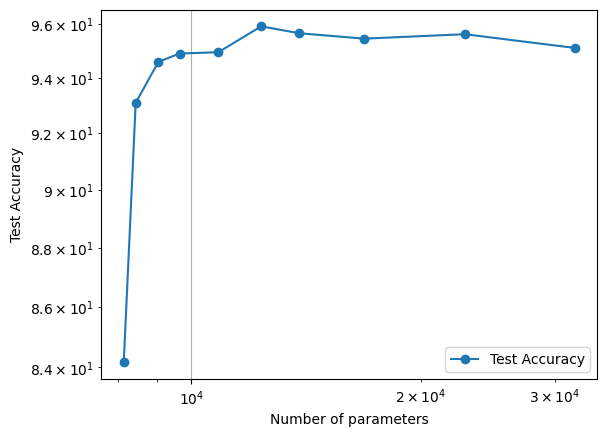

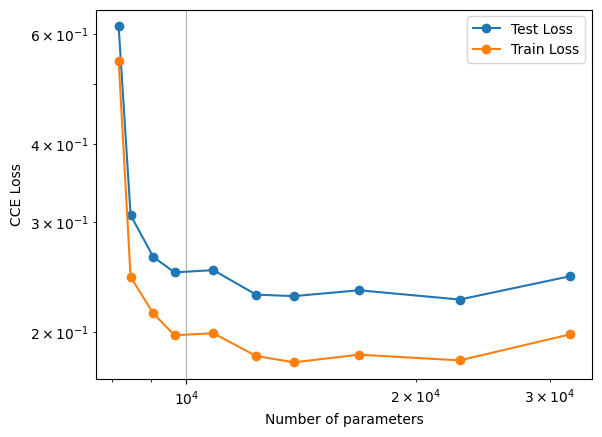

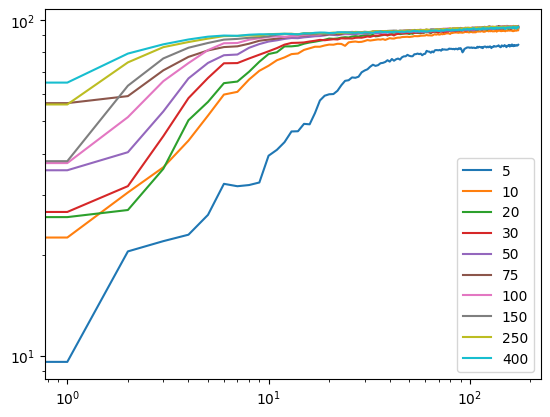

In [5]:
    analyze_and_plot(stats, N_neurons_vec, results, top_k=10)
    
    plt.figure()
    for k,n_neurons in enumerate(N_neurons_vec):
        plt.loglog(results[k]['test_acc'])
        plt.legend(N_neurons_vec)

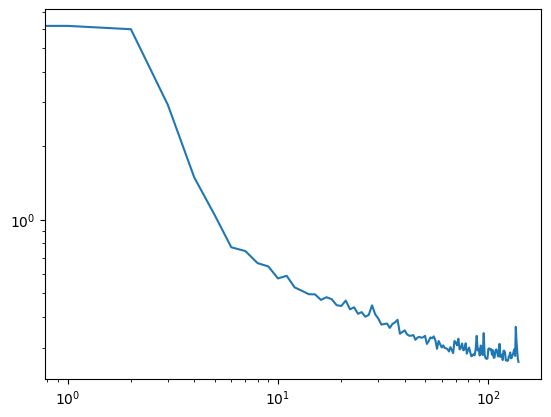

In [14]:
plt.loglog(D_2['test_loss'])

In [7]:
results_lora = results

In [8]:
len(results_lora)

10

In [9]:
with gzip.open('paramscan_FFNN_BP_Lora.pkl.gz',"wb") as f:
    pickle.dump(results_lora,f)

In [12]:
N_neurons_vec = [5, 10, 20, 30, 50, 75, 100,150,250,400]
#N_neurons_vec = [200]

n_epochs = 25
results = []

stats = 1

start_time = time.time()
for s in range(stats):
    for n_neurons in N_neurons_vec:
    
        #Initialize RNN
        
        NN_params = {
            "N_in": 784,               # e.g., flattened 28x28 FashionMNIST image
            "N_out": 10,               # number of classes in FashionMNIST
            "N_neurons": n_neurons,          # number of hidden units per RNN layer
            "N_layers": 3             # depth of the RNN
        }
        
        model = simple_FFNN_compressed(params = NN_params, r_compress=10, compression_method=None)
        

        
        
        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        
        print(f'Using {n_neurons} per layer, run {s+1}, number of parameters {model.count_parameters()}')
        D_2 = train_BP_torch(model, n_epochs, train_loader_MNIST, test_loader_MNIST, loss, optimizer)
    
        results.append(D_2)
        
        del model
        del optimizer
        torch.cuda.empty_cache()
        gc.collect()

end_time = time.time()
print(f'Total time = {end_time- start_time} s')

Using 5 per layer, run 1, number of parameters 4045
Using cuda device
simple_FFNN_compressed(
  (input_layer): Linear(in_features=784, out_features=5, bias=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=5, out_features=5, bias=True)
  )
  (output_layer): Linear(in_features=5, out_features=10, bias=True)
  (activation): Tanh()
)


Epoch [1/25], Step [1/60], Loss: 2.344655990600586, Test Accuracy: 12.69%
Epoch [1/25], Step [10/60], Loss: 2.2696034908294678, Test Accuracy: 24.64%
Epoch [1/25], Step [20/60], Loss: 2.2251641750335693, Test Accuracy: 22.4%
Epoch [1/25], Step [30/60], Loss: 2.1819446086883545, Test Accuracy: 24.89%
Epoch [1/25], Step [40/60], Loss: 2.129460573196411, Test Accuracy: 28.25%
Epoch [1/25], Step [50/60], Loss: 2.1034698486328125, Test Accuracy: 28.84%
Epoch [1/25], Step [60/60], Loss: 2.0655581951141357, Test Accuracy: 28.98%
Epoch [2/25], Step [1/60], Loss: 2.0566060543060303, Test Accuracy: 28.98%
Epoch [2/25], Step [10/60], Loss: 2.0089855194091797, Test Accuracy: 28.78%
Epoch [2/25], Step [20/60], Loss: 2.011272668838501, Test Accuracy: 29.14%
Epoch [2/25], Step [30/60], Loss: 1.9671119451522827, Test Accuracy: 29.25%
Epoch [2/25], Step [40/60], Loss: 1.9241454601287842, Test Accuracy: 30.13%
Epoch [2/25], Step [50/60], Loss: 1.9128512144088745, Test Accuracy: 30.86%
Epoch [2/25], Step

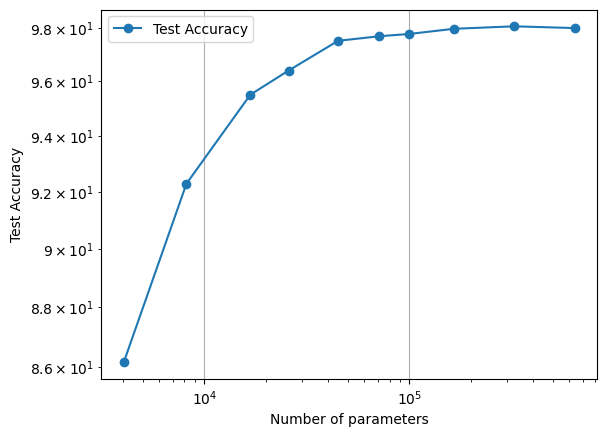

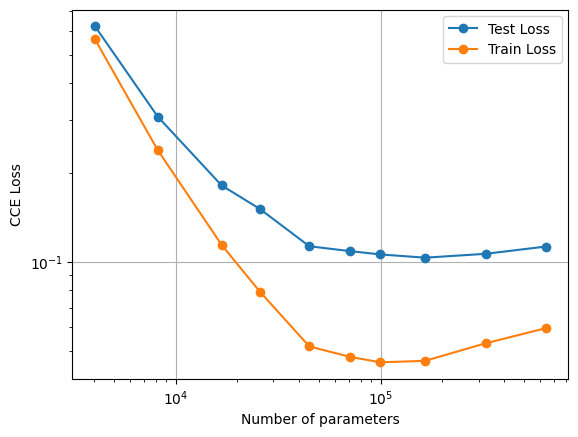

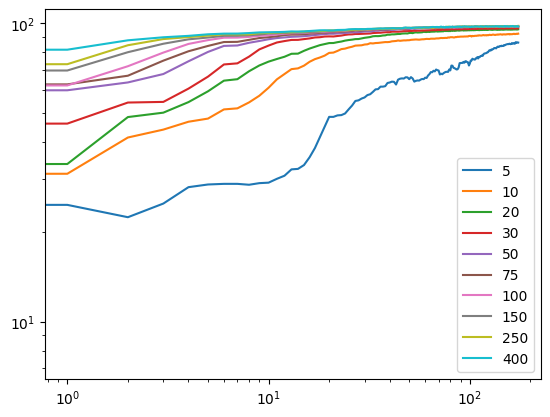

In [13]:
    analyze_and_plot(stats, N_neurons_vec, results, top_k=10)
    
    plt.figure()
    for k,n_neurons in enumerate(N_neurons_vec):
        plt.loglog(results[k]['test_acc'])
        plt.legend(N_neurons_vec)

In [14]:
with gzip.open('paramscan_FFNN_BP.pkl.gz',"wb") as f:
    pickle.dump(results,f)

In [15]:
with gzip.open('paramscan_FFNN_BP.pkl.gz', 'rb') as f:
    results_BP = pickle.load(f)

with gzip.open('paramscan_FFNN_BP_Lora.pkl.gz', 'rb') as f:
    results_BP_lora = pickle.load(f)

In [37]:
best_acc_BP = []
best_acc_BP_lora = []

best_loss_BP = []
best_loss_BP_lora = []

compression_ratio = []
performance_ratio = []
performance_ratio_acc = []

for k,n_neurons in enumerate(N_neurons_vec):


    best_acc_BP.append(np.max(results_BP[k]['test_acc']))
    best_acc_BP_lora.append(np.max(results_BP_lora[k]['test_acc']))

    best_loss_BP.append(np.min(results_BP[k]['test_loss']))
    best_loss_BP_lora.append(np.min(results_BP_lora[k]['test_loss']))
    
    compression_ratio.append(results_BP_lora[k]['n_params']/ results_BP[k]['n_params'])
    performance_ratio.append(np.min(results_BP_lora[k]['test_loss'])/ np.min(results_BP[k]['test_loss']))
    performance_ratio_acc.append(np.max(results_BP_lora[k]['test_acc'])/ np.max(results_BP[k]['test_acc']))



In [34]:
performance_ratio_acc

[np.float64(0.7549251379038614),
 np.float64(1.3765347885402455),
 np.float64(1.0670103092783505),
 np.float64(1.149812734082397),
 np.float64(0.7736406619385342),
 np.float64(1.1226912928759893),
 np.float64(0.519585772174696),
 np.float64(0.6719783523752256),
 np.float64(0.669449715370019),
 np.float64(0.6867910017304365)]

Text(0, 0.5, 'Test_loss')

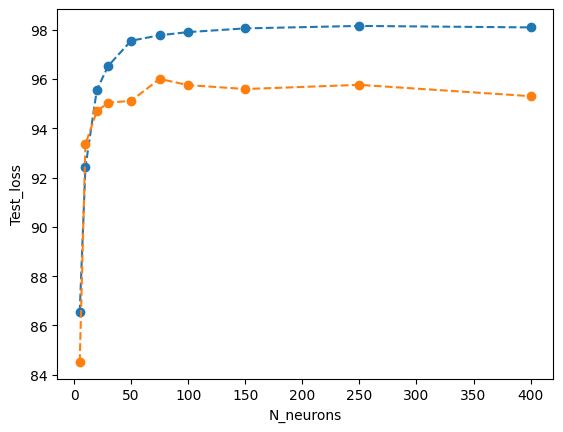

In [38]:
plt.figure()
plt.plot(N_neurons_vec,best_acc_BP,'--o',label = 'No compression')
plt.plot(N_neurons_vec,best_acc_BP_lora,'--o',label='Lora')

plt.xlabel('N_neurons')
plt.ylabel('Test_loss')

Text(0, 0.5, 'Test loss ratio')

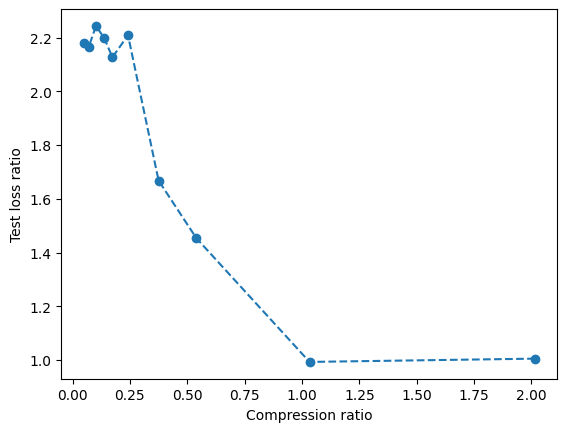

In [27]:
plt.figure()
plt.plot(compression_ratio,performance_ratio,'--o',label='Lora')

plt.xlabel('Compression ratio')
plt.ylabel('Test loss ratio')


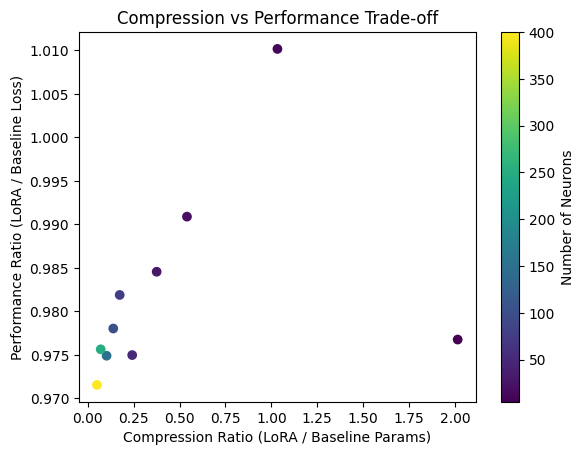

In [39]:
plt.scatter(compression_ratio, performance_ratio_acc, c=N_neurons_vec, cmap='viridis')
plt.xlabel('Compression Ratio (LoRA / Baseline Params)')
plt.ylabel('Performance Ratio (LoRA / Baseline Loss)')
plt.title('Compression vs Performance Trade-off')
plt.colorbar(label='Number of Neurons')

Text(0.5, 1.0, 'Relative Performance Change with LoRA')

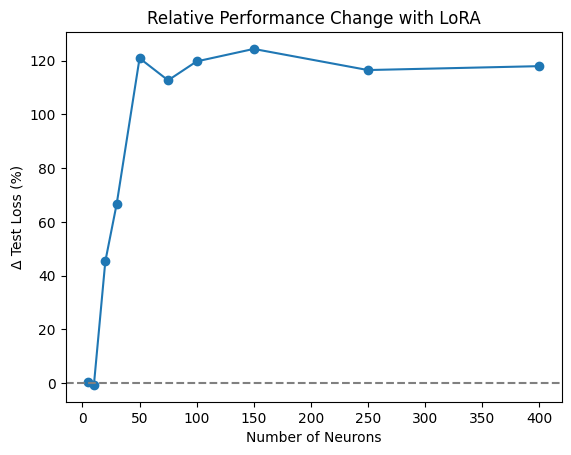

In [29]:
perf_drop = (np.array(best_acc_BP_lora) - np.array(best_acc_BP)) / np.array(best_acc_BP) * 100

plt.plot(N_neurons_vec, perf_drop, 'o-')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Number of Neurons')
plt.ylabel('Δ Test Loss (%)')
plt.title('Relative Performance Change with LoRA')

Text(0.5, 1.0, 'Compression and Performance across Model Sizes')

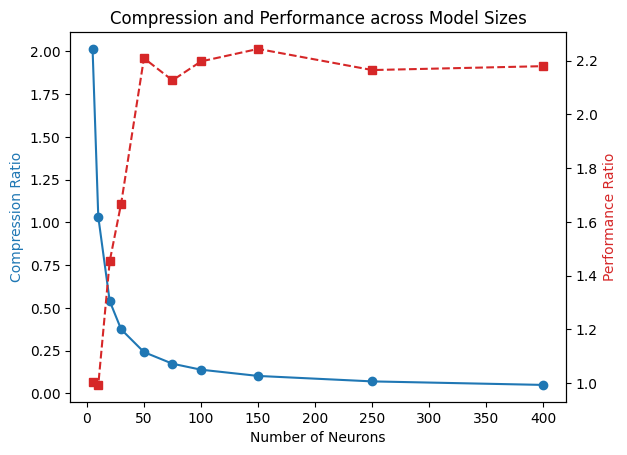

In [30]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(N_neurons_vec, compression_ratio, 'o-', color='tab:blue', label='Compression')
ax2.plot(N_neurons_vec, performance_ratio, 's--', color='tab:red', label='Performance Ratio')

ax1.set_xlabel('Number of Neurons')
ax1.set_ylabel('Compression Ratio', color='tab:blue')
ax2.set_ylabel('Performance Ratio', color='tab:red')
plt.title('Compression and Performance across Model Sizes')

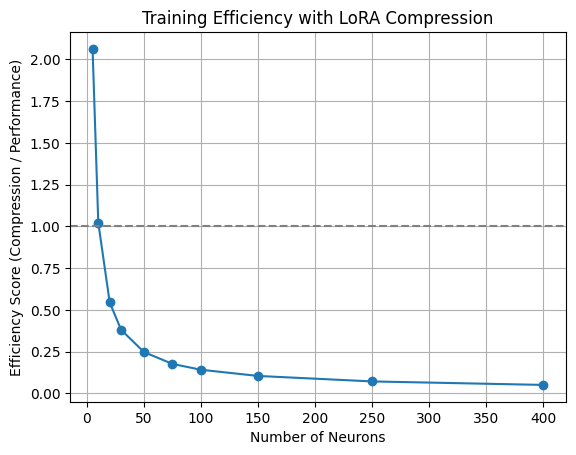

In [40]:
efficiency_score = np.array(compression_ratio) / np.array(performance_ratio_acc)

plt.plot(N_neurons_vec, efficiency_score, 'o-')
plt.axhline(1, color='gray', linestyle='--')
plt.xlabel('Number of Neurons')
plt.ylabel('Efficiency Score (Compression / Performance)')
plt.title('Training Efficiency with LoRA Compression')
plt.grid(True)


In [42]:
torch.cuda.is_available()

True